### 1. Impor Library
Mengimpor semua library yang diperlukan untuk analisis data, visualisasi, dan pemodelan.

Import Library

In [148]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, OneHotEncoder, StandardScaler
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### 2. Memuat Data
Membaca dataset dari file CSV dan menampilkan ringkasan informasi kolom.

Data Loading

In [149]:
df = pd.read_csv('ai_impact.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

### 3. Matriks Korelasi
Visualisasi heatmap untuk melihat hubungan antar variabel numerik.

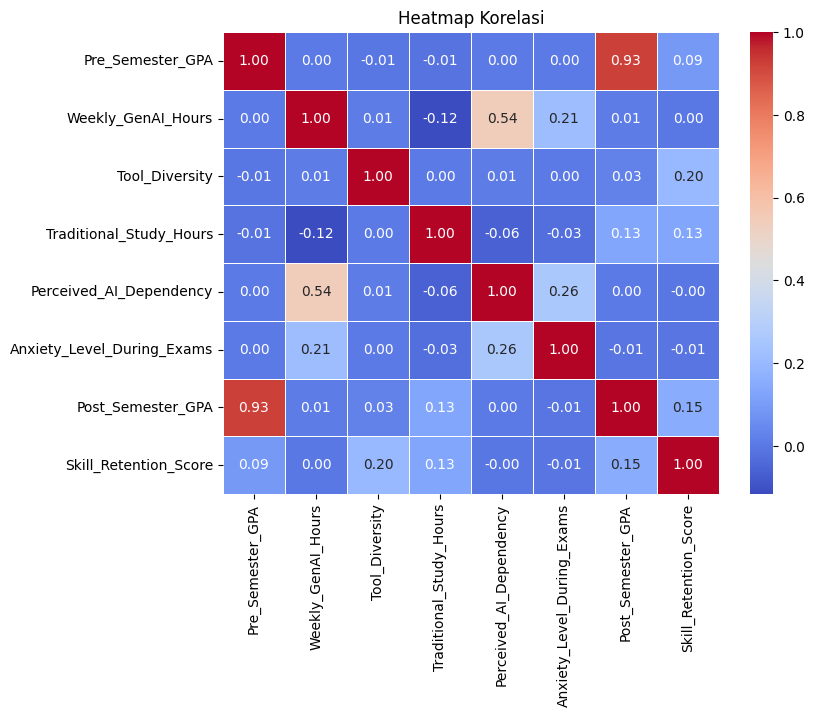

In [170]:
plt.figure(figsize=(8, 6))
correlation_matrix = df.select_dtypes(include=np.number).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi')
plt.show()

### 4. Visualisasi Pairplot
Menampilkan hubungan distribusi antar pasangan variabel numerik secara menyeluruh.

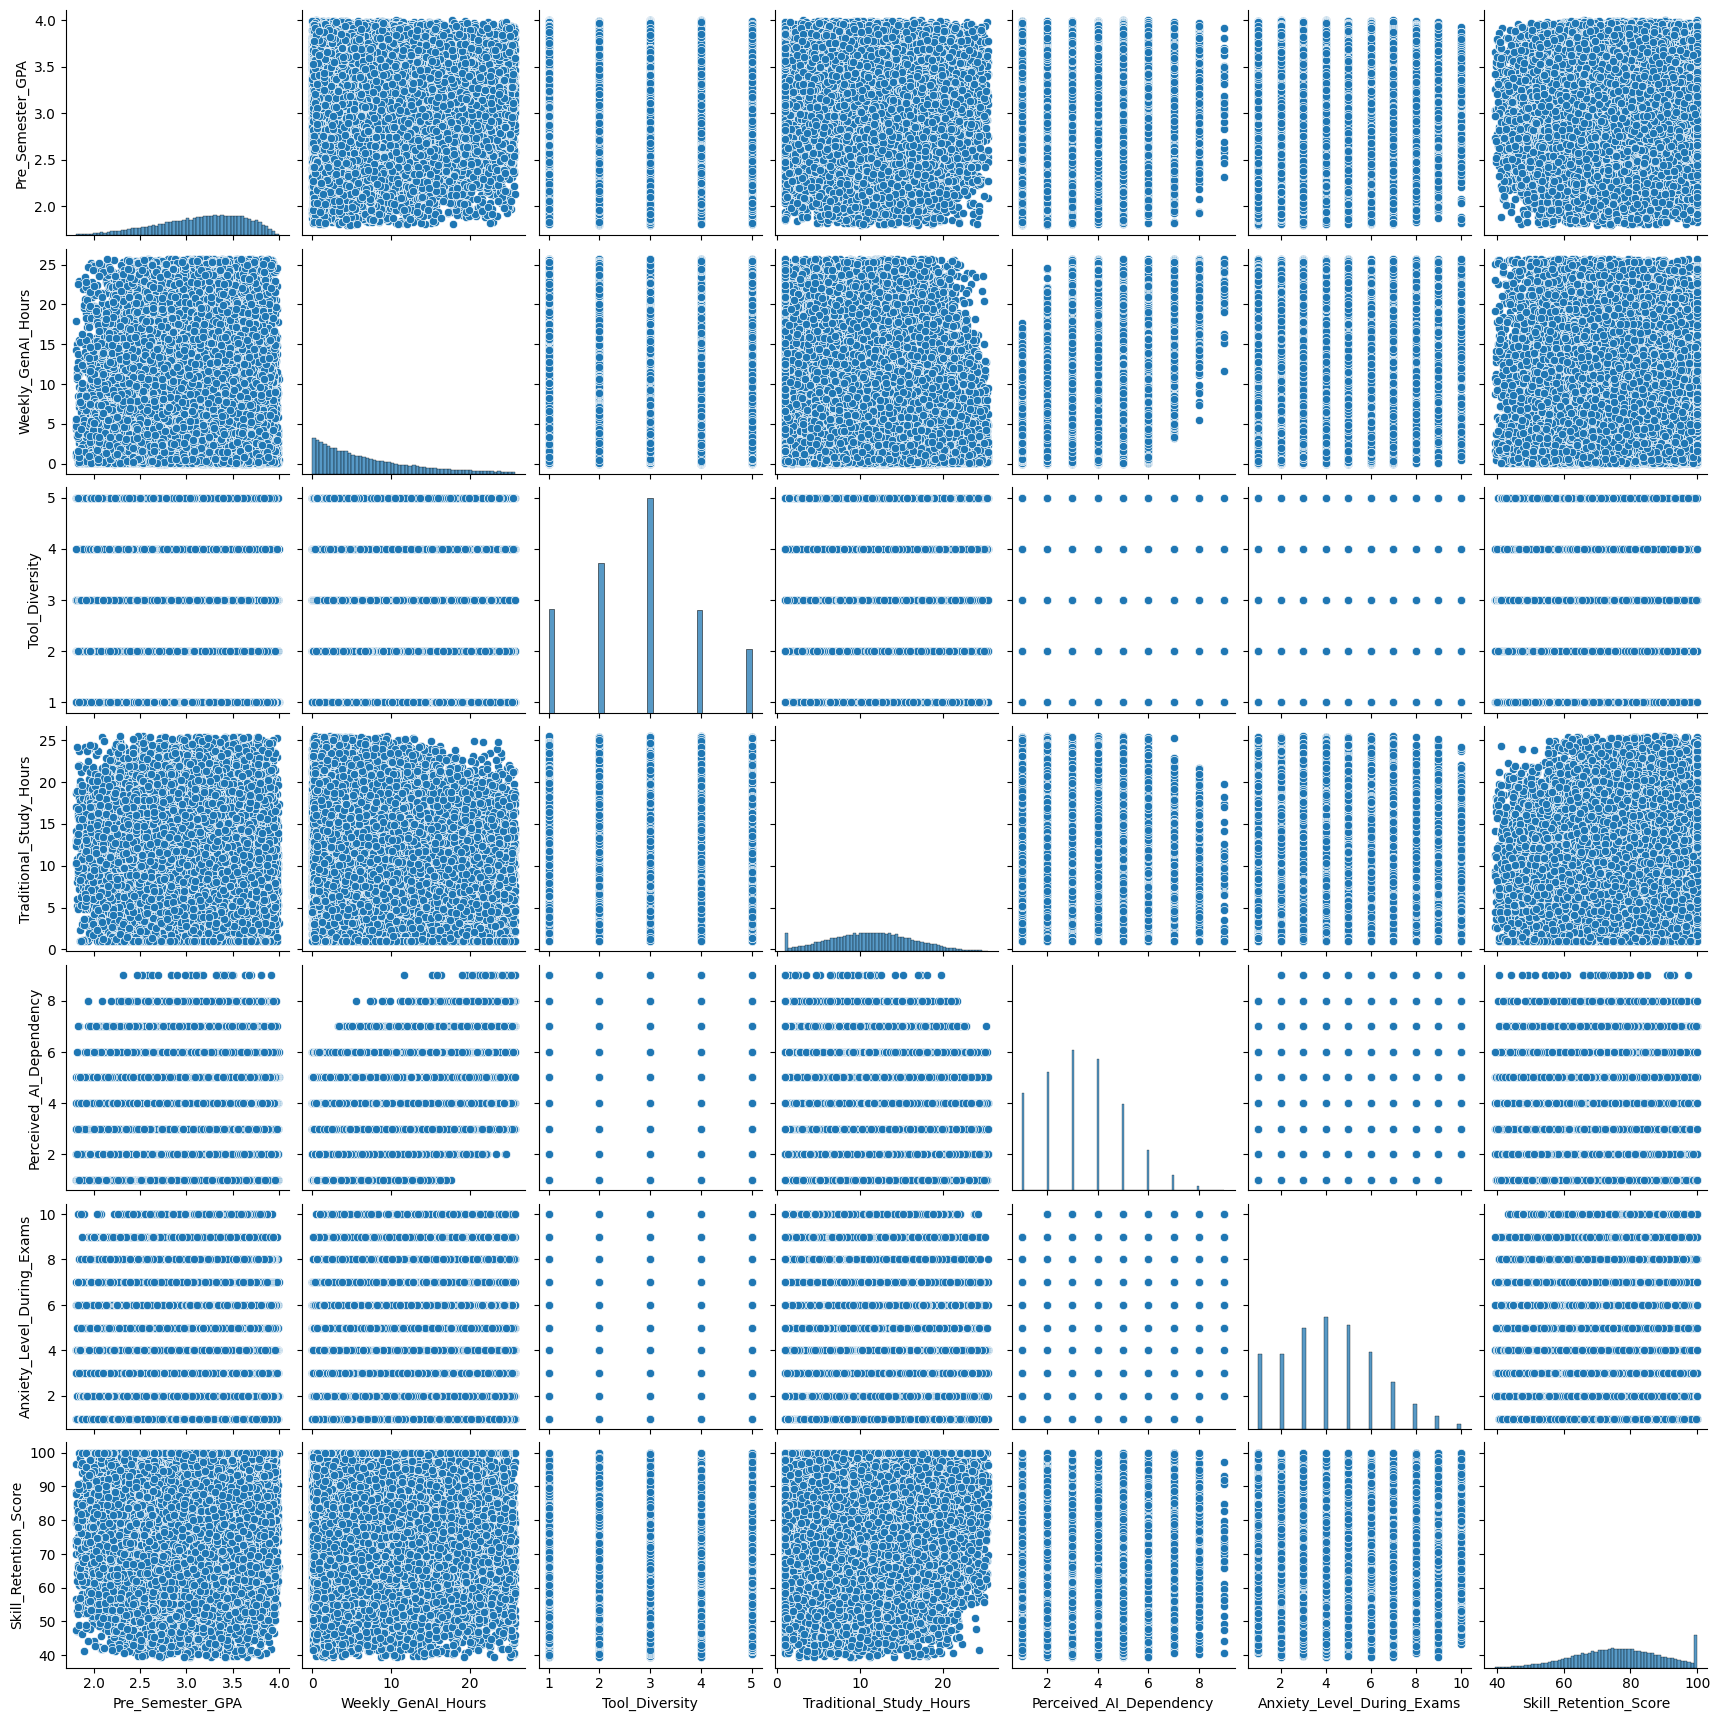

In [140]:
sns.pairplot(df.select_dtypes(include=np.number)
plt.show()

### 5. Seleksi Fitur Awal
Menghapus kolom yang tidak relevan dari dataframe.

In [151]:
df = df.drop(['Student_ID', 'Major_Category', 'Primary_Use_Case'], axis=1)
df.head()

,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,Senior,2.418,23.31,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,Junior,3.821,1.12,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,Freshman,3.398,21.26,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,Senior,3.789,1.82,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,Sophomore,3.635,9.29,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


### 6. Cek Outliers
Identifikasi outliers pada data numerik menggunakan boxplot.

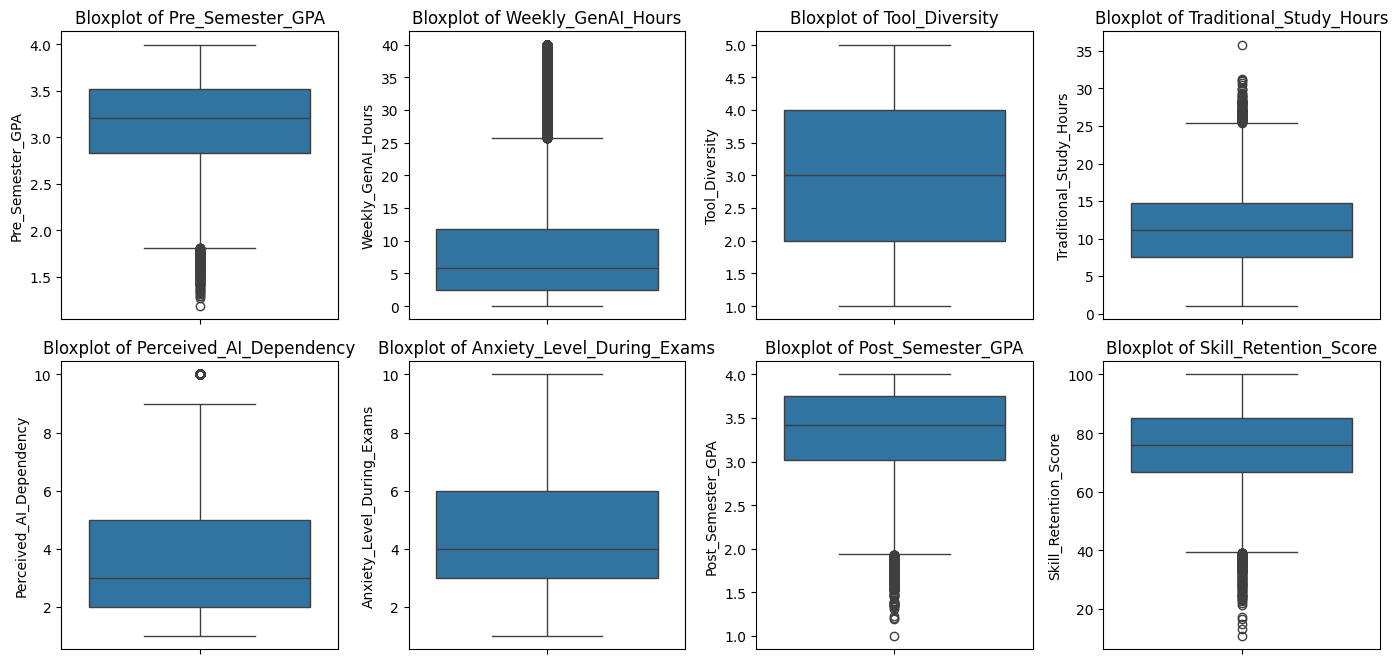

In [152]:
plt.figure(figsize=(14, 10))
for i, column in enumerate(df.select_dtypes(include=[np.number]).columns, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(df[column])
    plt.title(f'Bloxplot of {column}')
plt.tight_layout()
plt.show()

### 7. Penanganan Outliers
Membersihkan outliers menggunakan metode IQR.

In [153]:
numeric_df = df.select_dtypes(include=np.number)

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

condition = ~((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)
df = df.loc[condition]

### 8. Validasi Hasil Pembersihan

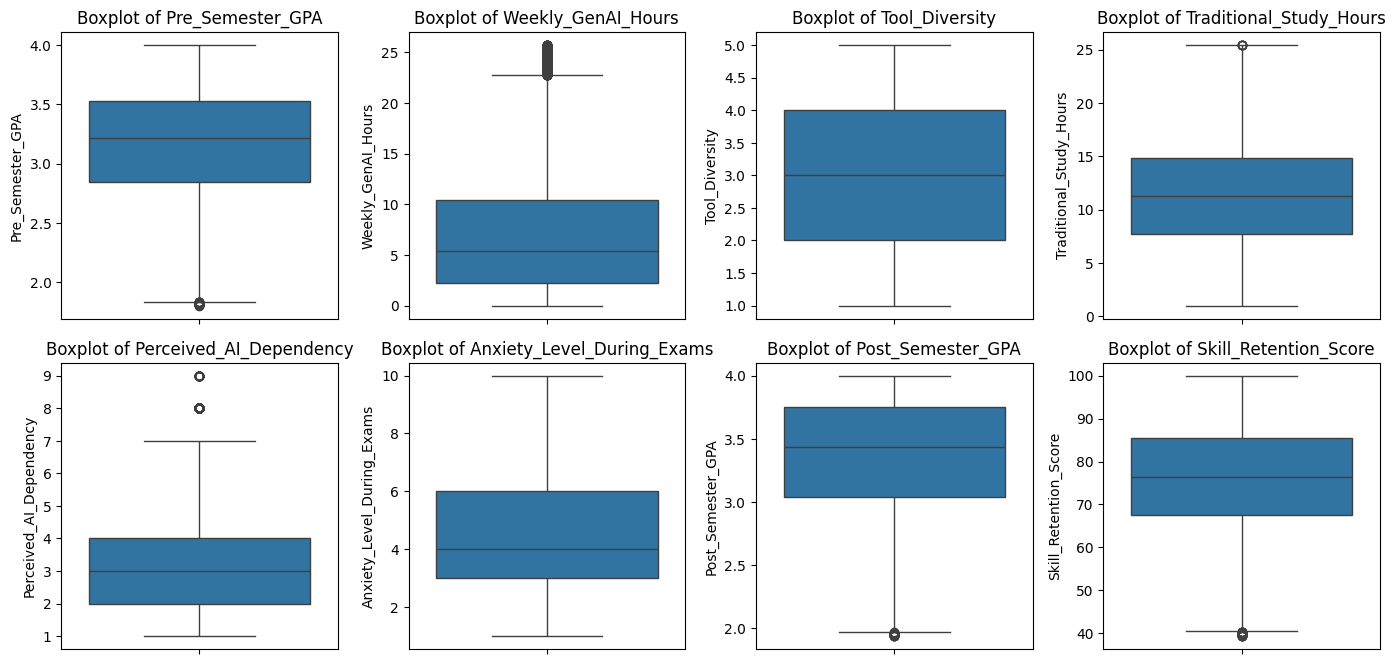

In [154]:
plt.figure(figsize=(14, 10))
for i, column in enumerate(df.select_dtypes(include=[np.number]).columns, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(df[column])
    plt.title(f'Boxplot of {column}')
plt.tight_layout()
plt.show()

### 9. Pembagian Dataset
Memecah data menjadi set pelatihan (train) dan set pengujian (test).

In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46731 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year_of_Study               46731 non-null  object 
 1   Pre_Semester_GPA            46731 non-null  float64
 2   Weekly_GenAI_Hours          46731 non-null  float64
 3   Prompt_Engineering_Skill    46731 non-null  object 
 4   Tool_Diversity              46731 non-null  int64  
 5   Paid_Subscription           46731 non-null  bool   
 6   Traditional_Study_Hours     46731 non-null  float64
 7   Perceived_AI_Dependency     46731 non-null  int64  
 8   Institutional_Policy        46731 non-null  object 
 9   Anxiety_Level_During_Exams  46731 non-null  int64  
 10  Post_Semester_GPA           46731 non-null  float64
 11  Skill_Retention_Score       46731 non-null  float64
 12  Burnout_Risk_Level          46731 non-null  object 
dtypes: bool(1), float64(5), int64(3), ob

In [156]:
X = df.drop('Post_Semester_GPA', axis=1)
Y = df['Post_Semester_GPA']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

### 10. Pengelompokan Fitur
Memisahkan kolom berdasarkan tipe data kategorikal dan numerik.

In [157]:
cat_features = X.select_dtypes(include='object')
num_features = X.select_dtypes(include=[np.number])

### 11. Standarisasi Data
Menyamakan skala fitur numerik menggunakan StandardScaler.

In [158]:
standar_scaler = StandardScaler()
X_train[num_features.columns] = standar_scaler.fit_transform(X_train[num_features.columns])
X_test[num_features.columns] = standar_scaler.transform(X_test[num_features.columns])

### 12. Encoding Kategorikal
Mengonversi fitur teks menjadi angka menggunakan Ordinal Encoding sesuai tingkatan.

In [159]:
feature_ordinal = ['Year_of_Study', 'Prompt_Engineering_Skill', 'Institutional_Policy', 'Burnout_Risk_Level']

year_of_study_sort = ['Freshman', 'Sophomore', 'Junior', 'Senior', 'Graduate']
prompt_engineering_skill_sort = ['Beginner', 'Intermediate', 'Advanced']
institutional_policy_sort = ['Strict_Ban', 'Allowed_With_Citation', 'Actively_Encouraged']
burnout_risk_level_sort = ['Low', 'Medium', 'High']

# ordinal encoding
ordinal_encoder = OrdinalEncoder(categories=[year_of_study_sort, prompt_engineering_skill_sort, institutional_policy_sort, burnout_risk_level_sort])
X_train[feature_ordinal] = ordinal_encoder.fit_transform(X_train[feature_ordinal])
X_test[feature_ordinal] = ordinal_encoder.transform(X_test[feature_ordinal])

### 13. Visualisasi Histogram
Menampilkan distribusi frekuensi untuk setiap variabel dalam set pelatihan.

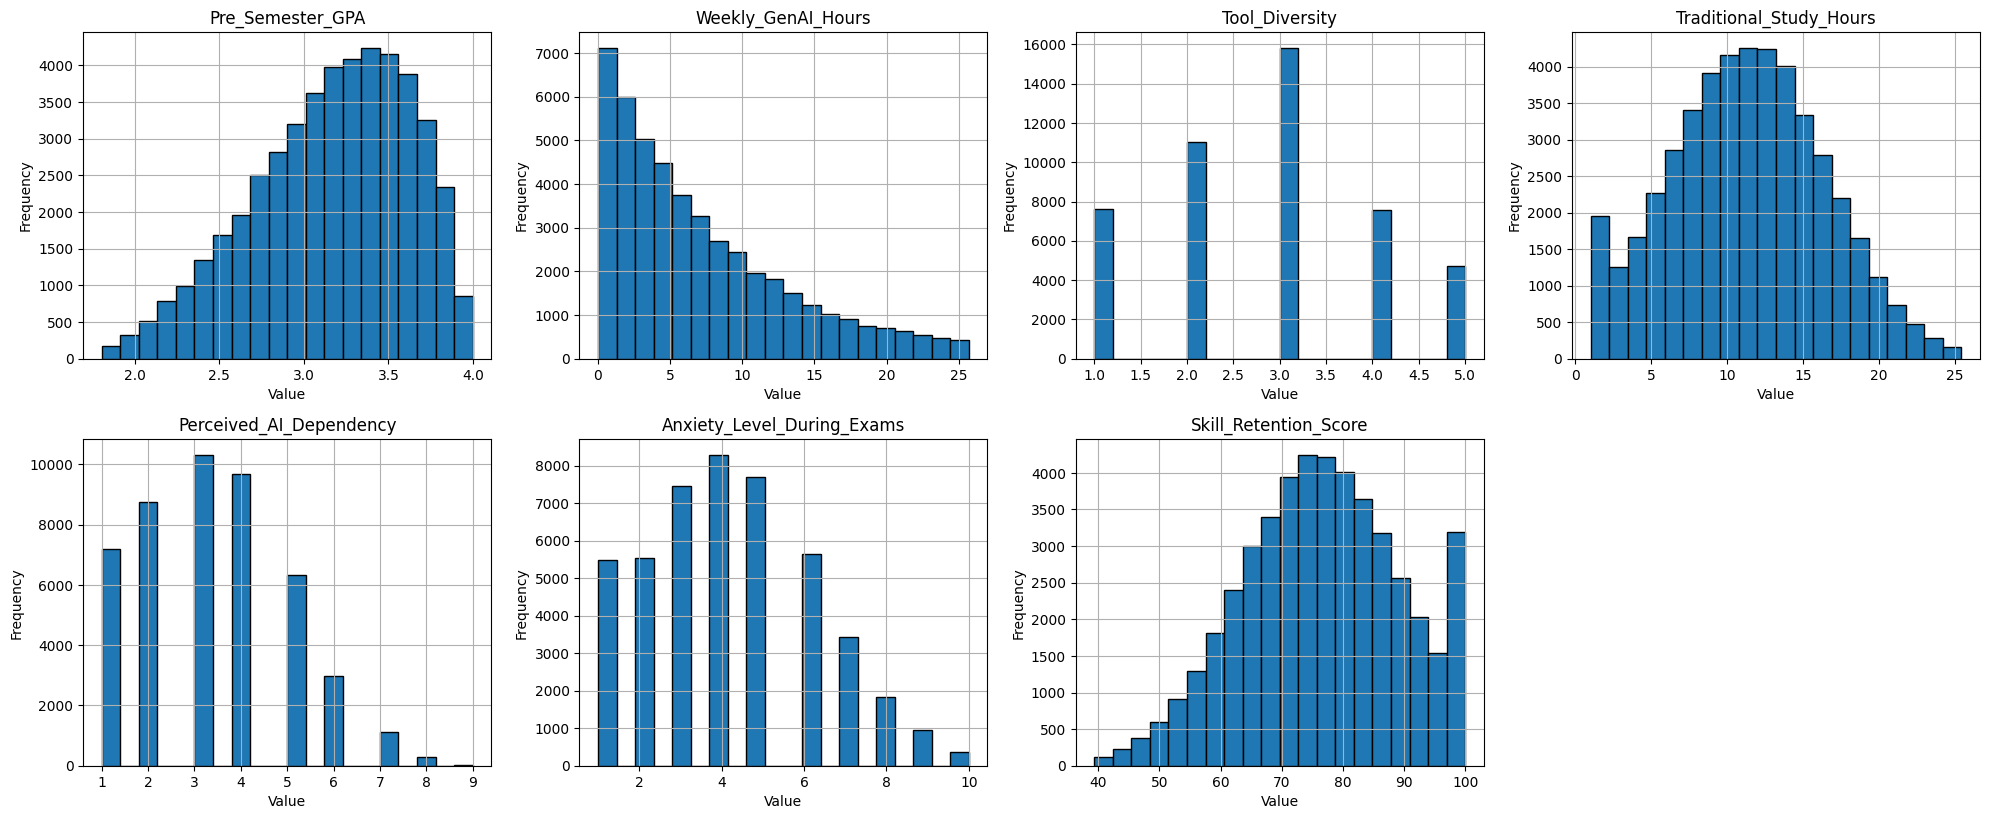

In [160]:
num_vars = df.shape[1]

n_cols = 4
n_rows = -(-num_vars // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))

axes = axes.flatten()

for i, column in enumerate(X_train[num_features.columns]):
    df[column].hist(ax=axes[i], bins=20, edgecolor='black')
    axes[i].set_title(column)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 14. Korelasi terhadap Target
Melihat seberapa kuat pengaruh setiap variabel terhadap Post_Semester_GPA.

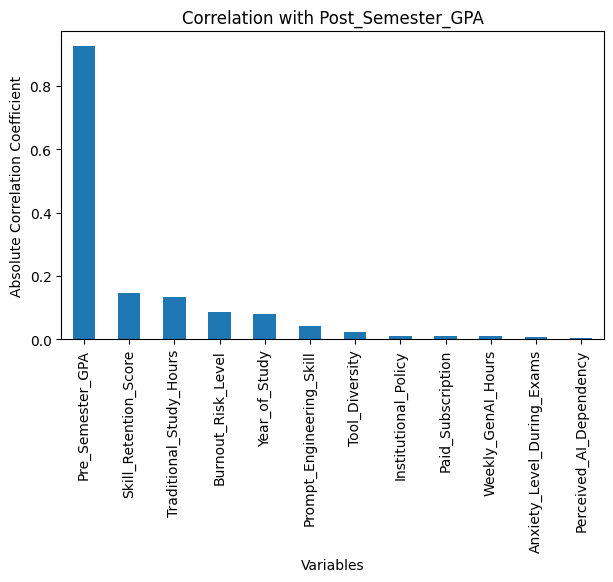

In [161]:
df_corr = pd.concat([X_train, y_train], axis=1)

target_corr = df_corr.corr()['Post_Semester_GPA']
target_corr = target_corr.drop('Post_Semester_GPA')
target_corr_sorted = target_corr.abs().sort_values(ascending=False)

plt.figure(figsize=(7, 4))
target_corr_sorted.plot(kind='bar')
plt.title('Correlation with Post_Semester_GPA')
plt.xlabel('Variables')
plt.ylabel('Absolute Correlation Coefficient')
plt.show()

### 15. Cek Dimensi Data
Memastikan jumlah baris dan kolom sudah benar sebelum pemodelan.

In [162]:
print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test set shape: X_test={X_test.shape}, y_test={y_test.shape}")

Training set shape: X_train=(37384, 12), y_train=(37384,)
Test set shape: X_test=(9347, 12), y_test=(9347,)


### 16. Eksperimen Model
Melatih model Lars, Linear Regression, dan GBR serta menghitung metrik evaluasi.

In [163]:
lars = linear_model.Lars(n_nonzero_coefs=1).fit(X_train, y_train)
LR = LinearRegression().fit(X_train, y_train)
GBR = GradientBoostingRegressor(random_state=184).fit(X_train, y_train)

pred_lars = lars.predict(X_test)
pred_LR = LR.predict(X_test)
pred_GBR = GBR.predict(X_test)


mae_lars = mean_absolute_error(y_test, pred_lars)
mse_lars = mean_squared_error(y_test, pred_lars)
r2_lars = r2_score(y_test, pred_lars)

mae_LR = mean_absolute_error(y_test, pred_LR)
mse_LR = mean_squared_error(y_test, pred_LR)
r2_LR = r2_score(y_test, pred_LR)

mae_GBR = mean_absolute_error(y_test, pred_GBR)
mse_GBR = mean_squared_error(y_test, pred_GBR)
r2_GBR = r2_score(y_test, pred_GBR)

### 17. Perbandingan Performa
Menyajikan tabel ringkasan MAE, MSE, dan R2 untuk semua model yang diuji.

In [164]:
data = {
    'MAE': [mae_lars, mae_LR, mae_GBR],
    'MSE': [mse_lars, mse_LR, mse_GBR],
    'R2': [r2_lars, r2_LR, r2_GBR]
}

df_results = pd.DataFrame(data, index=['Lars', 'Linear Regression', 'GBR'])
df_results

,MAE,MSE,R2
Lars,0.152407,0.036522,0.840109
Linear Regression,0.123610,0.024377,0.893279
GBR,0.117860,0.022553,0.901264
